JPMorgan Chase Quantitative Research - Task 1
Natural Gas Price Estimation with Seasonal Adjustment

This script analyzes historical natural gas price data and provides
price estimation for any given date using interpolation (for past dates)
and extrapolation with seasonal modeling (for future dates).

In [1]:
import pandas as pd
import numpy as np
from scipy import interpolate
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from datetime import timedelta

In [2]:
# 1.LOADING AND PREPARING DATA

# Loading data
df = pd.read_csv('Nat_Gas.csv')

# Format conversion
df['Dates'] = pd.to_datetime(df['Dates'], format='%m/%d/%y')
df['Prices'] = df['Prices'].astype(float)
df = df.sort_values('Dates').reset_index(drop=True)

# Seasonality analysis (average prices per month)
df['Month'] = df['Dates'].dt.month
monthly_avg = df.groupby('Month')['Prices'].mean()

print(f"Données chargées: {len(df)} points de {df['Dates'].min().date()} à {df['Dates'].max().date()}")
print(f"Prix moyen: ${df['Prices'].mean():.2f}")

Données chargées: 48 points de 2020-10-31 à 2024-09-30
Prix moyen: $11.21


In [3]:
# 2.MAIN FUNCTION: PRICE ESTIMATION
def estimate_price(target_date):
    
    """
    Estimates the price of natural gas for a given date.

    Approach:
    - For past dates (within the data range): cubic interpolation
    - For future dates: extrapolation using a seasonal model

    Args:
    target_date(str or datetime): Target date (format 'YYYY-MM-DD')

    Returns:
    float: Estimated price in dollars
    """
    
    # Date conversion
    if isinstance(target_date, str):
        target_date = pd.to_datetime(target_date)
    
    #Preparation of digital data
    dates = df['Dates'].values
    prices = df['Prices'].values
    dates_numeric = np.array([(d - dates[0]).days for d in pd.to_datetime(dates)])
    target_numeric = (target_date - pd.to_datetime(dates[0])).days
    
    min_date = pd.to_datetime(dates[0])
    max_date = pd.to_datetime(dates[-1])
    
    #INTERPOLATION for dates within the existing range
    if min_date <= target_date <= max_date:
        interpolator = interpolate.interp1d(dates_numeric, prices, 
                                            kind='cubic', 
                                            fill_value='extrapolate')
        estimated_price = float(interpolator(target_numeric))
    
    #EXTRAPOLATION for future dates
    else:
        #Seasonal model: Price = Trend + Seasonality
        def seasonal_model(t, trend, amplitude, phase, offset):
            """
            Model combining linear trend and annual seasonality
            - trend: slope of the trend
            - amplitude: strength of the seasonal variation
            - phase: time lag of the seasonality
            - offset: base price
            """
            return trend * t + amplitude * np.sin(2 * np.pi * t / 365.25 + phase) + offset
        
        try:
            #Adjusting the model based on historical data
            params, _ = curve_fit(seasonal_model, dates_numeric, prices, 
                                 p0=[0.001, 1, 0, 11], maxfev=10000)
            estimated_price = float(seasonal_model(target_numeric, *params))
        
        except:
            #Fallback: linear extrapolation + seasonal adjustment per month
            linear_fit = np.polyfit(dates_numeric, prices, 1)
            linear_pred = np.poly1d(linear_fit)
            
            target_month = target_date.month
            seasonal_adjustment = monthly_avg[target_month] - df['Prices'].mean()
            estimated_price = float(linear_pred(target_numeric) + seasonal_adjustment)
    
    #Ensure a positive price
    return max(estimated_price, 0)


In [9]:
#3.TESTING AND VALIDATION

print("\n=== FUNCTION TESTS ===\n")

#Test 1: Interpolation (past date)
test1 = "2022-06-15"
print(f"Test 1 - Past date: {test1}")
print(f"Estimated price: ${estimate_price(test1):.2f}\n")

#Test 2: Validation on existing data
test2 = "2023-12-31"
actual = df[df['Dates'] == test2]['Prices'].values[0]
estimated = estimate_price(test2)
print(f"Test 2 - Validation: {test2}")
print(f"Real price: ${actual:.2f}, Estimated: ${estimated:.2f}, Error: ${abs(actual-estimated):.3f}\n")

#Test 3: Extrapolation (winter 2025 - high prices expected)
test3 = "2025-01-31"
print(f"Test 3 - Future date (winter): {test3}")
print(f"Estimated price: ${estimate_price(test3):.2f}\n")

#Test 4: Extrapolation (summer 2025 - low prices expected)
test4 = "2025-06-30"
print(f"Test 4 - Future date (summer): {test4}")
print(f"Estimated price: ${estimate_price(test4):.2f}\n")


=== FUNCTION TESTS ===

Test 1 - Past date: 2022-06-15
Estimated price: $10.55

Test 2 - Validation: 2023-12-31
Real price: $12.80, Estimated: $12.80, Error: $0.000

Test 3 - Future date (winter): 2025-01-31
Estimated price: $13.15

Test 4 - Future date (summer): 2025-06-30
Estimated price: $12.11



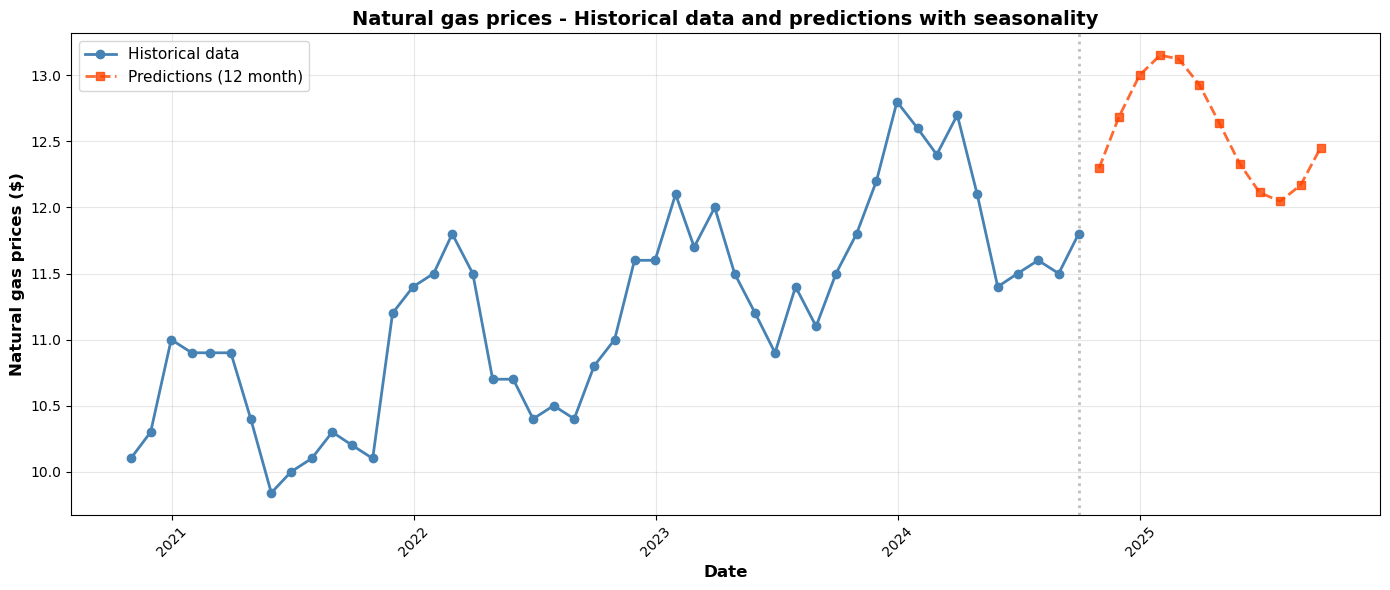

✓ Saved graph: natural_gas_prediction.png

=== ANALYSIS COMPLETED ===
The estimate_price() function is ready to estimate the price on any date


In [10]:
# 4. VISUALISATION
#Generate predictions for the next 12 months
future_dates = pd.date_range(start=df['Dates'].max() + timedelta(days=30), 
                              periods=12, freq='M')
future_prices = [estimate_price(date) for date in future_dates]

# Create graph
plt.figure(figsize=(14, 6))

# Historical data
plt.plot(df['Dates'], df['Prices'], 'o-', label='Historical data', 
         linewidth=2, markersize=6, color='steelblue')

# Future predictions
plt.plot(future_dates, future_prices, 's--', label='Predictions (12 month)', 
         linewidth=2, markersize=6, color='orangered', alpha=0.8)

# Demarcation line
plt.axvline(x=df['Dates'].max(), color='gray', linestyle=':', alpha=0.5, linewidth=2)

plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Natural gas prices ($)', fontsize=12, fontweight='bold')
plt.title('Natural gas prices - Historical data and predictions with seasonality', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('natural_gas_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved graph: natural_gas_prediction.png")
print("\n=== ANALYSIS COMPLETED ===")
print("The estimate_price() function is ready to estimate the price on any date")
